# Employee Attrition — Project Cycle

End-to-end workflow for predicting employee attrition: data cleaning, feature engineering, exploratory plots, and modelling with Random Forest / XGBoost, plus SHAP for interpretability.

## Running this notebook
1. Install dependencies: `pip install -r requirements.txt`
2. Place the dataset at `data/employees.csv` (not committed — see `.gitignore`).
3. Run cells top to bottom.


In [ ]:
!pip install pandas

In [3]:
data_path = "data/employees.csv"

In [4]:
import pandas as pd
import os

# Ensure data_path is correctly pointing to the file
# data_path is assumed to be defined in a previous cell, e.g., data_path = "/data/employees.csv"
expanded_data_path = os.path.expanduser(data_path)

# Check if the file exists before attempting to read it
if not os.path.exists(expanded_data_path):
    raise FileNotFoundError(f"The file '{expanded_data_path}' does not exist. Please upload the file to your Colab environment or provide a correct path.")

df = pd.read_csv(expanded_data_path)
df.head()

,employee_id,name,hire_date,exit_date,status,department,role_family,role_level,job_title,salary,...,contract_type,hipo_flag,promotion_eligible,manager_id,hire_source,legacy_entity_code,data_source_system,days_to_fill,tenure_months,acting_appointment
0,E00001,Madison Lang,1988-01-11,NaN,active,Wealth Management,Operations-Processing,2,"Manager, Wealth Management",115200.0,...,Full-time,False,False,E04330,referral,NovaCorp-Origin,WorkdayHR,22.0,462,False
1,E00003,Amy Garza,1988-01-13,NaN,active,Wealth Management,Corporate-Support,3,"Senior Manager, Wealth Management",170200.0,...,Full-time,False,False,E13109,direct,NovaCorp-Origin,WorkdayHR,62.0,462,False
2,E00004,Meghan Robertson,1988-01-14,NaN,active,Insurance,Management,2,"Manager, Insurance",125500.0,...,Full-time,False,False,E14294,referral,NovaCorp-Origin,WorkdayHR,86.0,462,False
3,E00005,Gabrielle Crawford,1988-01-14,2024-12-24,departed,Wealth Management,Technology,2,"Manager, Wealth Management",132400.0,...,Full-time,False,True,E12337,direct,NovaCorp-Origin,WorkdayHR,63.0,449,False
4,E00006,Karen Hernandez,1988-01-15,2025-04-17,departed,Corporate Operations,Risk-Compliance,2,"Manager, Corporate Operations",120600.0,...,Full-time,False,False,E00218,agency,NovaCorp-Origin,WorkdayHR,20.0,453,False


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df1 = df.drop_duplicates(subset=["employee_id"], keep="first")

In [7]:
print(len(df), len(df1))

13403 13403


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13403 entries, 0 to 13402
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   employee_id          13403 non-null  object 
 1   name                 13403 non-null  object 
 2   hire_date            13403 non-null  object 
 3   exit_date            1400 non-null   object 
 4   status               13403 non-null  object 
 5   department           13403 non-null  object 
 6   role_family          13403 non-null  object 
 7   role_level           13403 non-null  int64  
 8   job_title            13403 non-null  object 
 9   salary               13403 non-null  float64
 10  compa_ratio          13403 non-null  float64
 11  gender               13403 non-null  object 
 12  age_band             13403 non-null  object 
 13  cultural_background  13403 non-null  object 
 14  contract_type        13403 non-null  object 
 15  hipo_flag            13403 non-null 

In [9]:
df.isnull()

,employee_id,name,hire_date,exit_date,status,department,role_family,role_level,job_title,salary,...,contract_type,hipo_flag,promotion_eligible,manager_id,hire_source,legacy_entity_code,data_source_system,days_to_fill,tenure_months,acting_appointment
0,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13398,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13399,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13400,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13401,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

,0
employee_id,0
name,0
hire_date,0
exit_date,12003
status,0
department,0
role_family,0
role_level,0
job_title,0
salary,0


In [11]:
# ==========================================
# EMPLOYEE ATTRITION DATA CLEANING
# ==========================================

import pandas as pd
import numpy as np

# -----------------------------
# 1. Check dataset overview
# -----------------------------

print("Dataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())


# -----------------------------
# 2. Convert date columns
# -----------------------------

df['hire_date'] = pd.to_datetime(df['hire_date'], errors='coerce')
df['exit_date'] = pd.to_datetime(df['exit_date'], errors='coerce')


# -----------------------------
# 3. Create exit status feature
# -----------------------------
# 1 = employee has exited
# 0 = employee is still active

df['has_exited'] = df['exit_date'].notna().astype(int)

print("\nExit status distribution:")
print(df['has_exited'].value_counts())


# -----------------------------
# 4. Handle missing manager_id
# -----------------------------

print("\nEmployees with missing manager:")
print(df[df['manager_id'].isna()])

# Replace missing manager with label

df['manager_id'] = df['manager_id'].fillna('No Manager')


# -----------------------------
# 5. Check duplicate records
# -----------------------------

print("\nDuplicate rows:")
print(df.duplicated().sum())

# Remove duplicates

df = df.drop_duplicates()


# -----------------------------
# 6. Check numerical variables
# -----------------------------

print("\nSalary summary:")
print(df['salary'].describe())

print("\nTenure summary:")
print(df['tenure_months'].describe())


# -----------------------------
# 7. Check categorical consistency
# -----------------------------

categorical_columns = [
    'department',
    'role_family',
    'role_level',
    'job_title',
    'gender',
    'age_band',
    'cultural_background',
    'contract_type',
    'hire_source'
]

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


# -----------------------------
# 8. Remove unnecessary identifiers
# -----------------------------
# Keep these for reference but exclude from modelling

drop_columns = [
    'employee_id',
    'name',
    'manager_id',
    'data_source_system',
    'legacy_entity_code'
]

df_model = df.drop(columns=drop_columns, errors='ignore')


# -----------------------------
# 9. Final cleaning check
# -----------------------------

print("\nFinal dataset shape:")
print(df_model.shape)

print("\nRemaining missing values:")
print(df_model.isnull().sum())


# -----------------------------
# 10. Save cleaned dataset
# -----------------------------

df_model.to_csv("cleaned_employee_attrition_dataset.csv", index=False)

print("\nCleaning complete! File saved.")

Dataset shape:
(13403, 24)

Missing values:
employee_id                0
name                       0
hire_date                  0
exit_date              12003
status                     0
department                 0
role_family                0
role_level                 0
job_title                  0
salary                     0
compa_ratio                0
gender                     0
age_band                   0
cultural_background        0
contract_type              0
hipo_flag                  0
promotion_eligible         0
manager_id                 1
hire_source                0
legacy_entity_code         0
data_source_system         0
days_to_fill               0
tenure_months              0
acting_appointment         0
dtype: int64

Exit status distribution:
has_exited
0    12003
1     1400
Name: count, dtype: int64

Employees with missing manager:
     employee_id               name  hire_date exit_date  status  \
6765      E07508  Mr. Ronald Wilson 2018-03-15       NaT  ac

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
import numpy as np

In [14]:
from sklearn.impute import SimpleImputer

In [15]:
imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")

In [16]:
X = df.drop([], axis=1)

In [18]:
y = df["has_exited"] # Temporarily using 'has_exited' as the target
X = df.drop(["has_exited"], axis=1) # Drop 'has_exited' from features

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Active employees in df: {len(df[df["has_exited"]==0])}")
print(f"Exited employees in df: {len(df[df["has_exited"]==1])}")

Active employees in df: 12003
Exited employees in df: 1400


In [19]:
X_train.head()

,employee_id,name,hire_date,exit_date,status,department,role_family,role_level,job_title,salary,...,contract_type,hipo_flag,promotion_eligible,manager_id,hire_source,legacy_entity_code,data_source_system,days_to_fill,tenure_months,acting_appointment
10253,E11351,Juan Parker,2024-05-16,NaT,active,Risk & Compliance,Operations-Processing,1,Processing Officer,68800.0,...,Full-time,True,False,E12811,acquisition,Entity_B,BambooHR-EntityB,69.0,19,False
10511,E11609,Robert Cole,2024-06-01,NaT,active,Risk & Compliance,Technology,1,Senior Engineer,131400.0,...,Full-time,False,False,E04646,acquisition,Entity_B,BambooHR-EntityB,18.0,19,False
12514,E13612,Christine Randolph,2025-04-22,NaT,active,Corporate Operations,Technology,1,Engineer,93000.0,...,Full-time,False,False,E11754,acquisition,Entity_C,PeopleSoft-Legacy,86.0,8,False
207,E00228,Martha James,1988-12-07,NaT,active,Retail Banking,Operations-Processing,2,"Manager, Retail Banking",133300.0,...,Full-time,False,False,E01733,agency,NovaCorp-Origin,WorkdayHR,39.0,451,False
3424,E03794,Dr. Katherine Gray,2002-12-01,NaT,active,Insurance,Corporate-Support,1,Graduate,55000.0,...,Full-time,False,False,E02551,agency,NovaCorp-Origin,WorkdayHR,27.0,281,False


In [21]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Remove duplicate employees
df1 = df.drop_duplicates(subset=["employee_id"], keep="first")

# Define target variable (what we want to predict)
y = df1["has_exited"]

# Define features (information used to predict)
X = df1.drop(
    [
        "has_exited",
        "employee_id"
    ],
    axis=1
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

# Create preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_cols
        ),
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="mean"))
            ]),
            numeric_cols
        )
    ]
)

# Check split sizes
print("Training data:", len(X_train))
print("Testing data:", len(X_test))

# Check target distribution
print("Active employees:", len(df1[df1["has_exited"] == 0]))
print("Exited employees:", len(df1[df1["has_exited"] == 1]))

# Preview training data
X_train.head()

Training data: 10722
Testing data: 2681
Active employees: 12003
Exited employees: 1400


,name,hire_date,exit_date,status,department,role_family,role_level,job_title,salary,compa_ratio,...,contract_type,hipo_flag,promotion_eligible,manager_id,hire_source,legacy_entity_code,data_source_system,days_to_fill,tenure_months,acting_appointment
10253,Juan Parker,2024-05-16,NaT,active,Risk & Compliance,Operations-Processing,1,Processing Officer,68800.0,0.84,...,Full-time,True,False,E12811,acquisition,Entity_B,BambooHR-EntityB,69.0,19,False
10511,Robert Cole,2024-06-01,NaT,active,Risk & Compliance,Technology,1,Senior Engineer,131400.0,0.86,...,Full-time,False,False,E04646,acquisition,Entity_B,BambooHR-EntityB,18.0,19,False
12514,Christine Randolph,2025-04-22,NaT,active,Corporate Operations,Technology,1,Engineer,93000.0,0.98,...,Full-time,False,False,E11754,acquisition,Entity_C,PeopleSoft-Legacy,86.0,8,False
207,Martha James,1988-12-07,NaT,active,Retail Banking,Operations-Processing,2,"Manager, Retail Banking",133300.0,0.92,...,Full-time,False,False,E01733,agency,NovaCorp-Origin,WorkdayHR,39.0,451,False
3424,Dr. Katherine Gray,2002-12-01,NaT,active,Insurance,Corporate-Support,1,Graduate,55000.0,1.00,...,Full-time,False,False,E02551,agency,NovaCorp-Origin,WorkdayHR,27.0,281,False


In [22]:
import os

# Create the directory if it doesn't exist
os.makedirs("../data/processed_data", exist_ok=True)

X_train.to_csv("../data/processed_data/X_train.csv", index=False)
X_test.to_csv("../data/processed_data/X_test.csv", index=False)
y_train.to_csv("../data/processed_data/y_train.csv", index=False)
y_test.to_csv("../data/processed_data/y_test.csv", index=False)

In [23]:
X_train = pd.read_csv("../data/processed_data/X_train.csv")
y_train = pd.read_csv("../data/processed_data/y_train.csv")
target_col = "churned_30d"

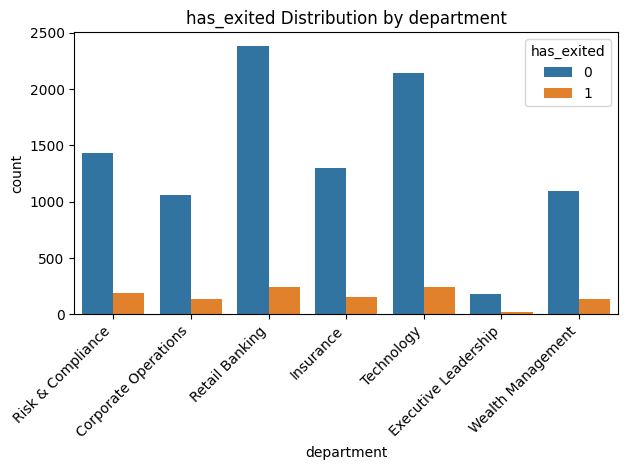

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

target_col = "has_exited" # Correcting target column to match y_train
x_axis_col = "department" # Using an existing categorical column from X_train

temp_df = X_train.copy()
temp_df[target_col] = y_train[target_col]

sns.countplot(data=temp_df, x=x_axis_col, hue=target_col)
plt.title(f"{target_col} Distribution by {x_axis_col}")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

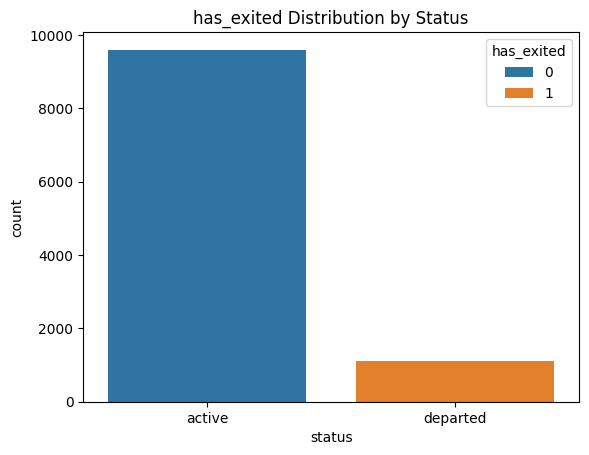

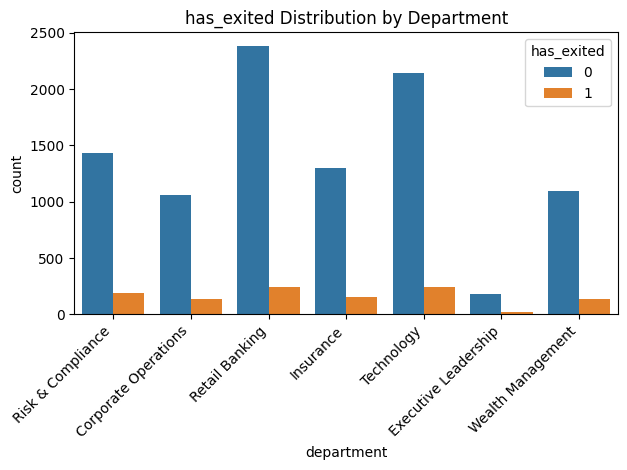

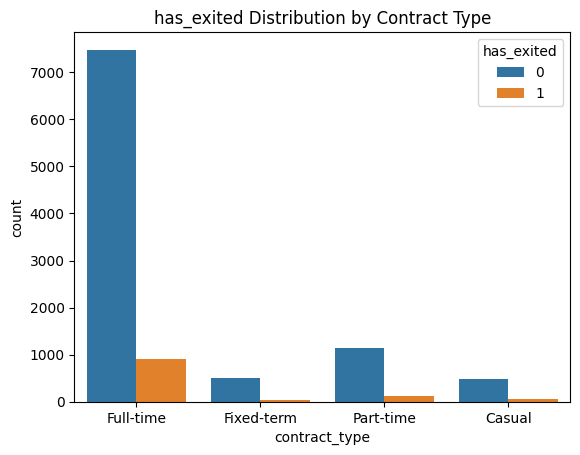

In [27]:
import matplotlib.pyplot as plt

# Using existing categorical columns from temp_df

sns.countplot(data=temp_df, x="status", hue=target_col) # Using 'status' as a placeholder
plt.title(f"{target_col} Distribution by Status")
plt.show()

sns.countplot(data=temp_df, x="department", hue=target_col) # Using 'department' as a placeholder
plt.title(f"{target_col} Distribution by Department")
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.tight_layout() # Adjust layout
plt.show()

sns.countplot(data=temp_df, x="contract_type", hue=target_col) # Using 'contract_type' as a placeholder
plt.title(f"{target_col} Distribution by Contract Type")
plt.show()

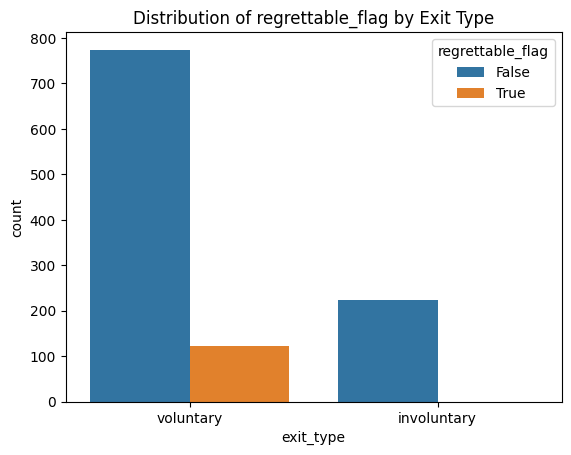

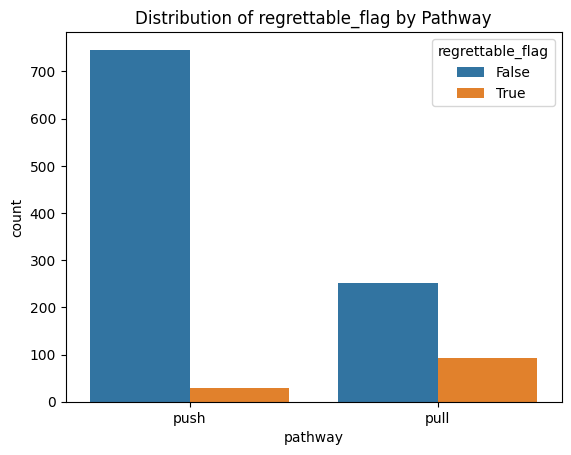

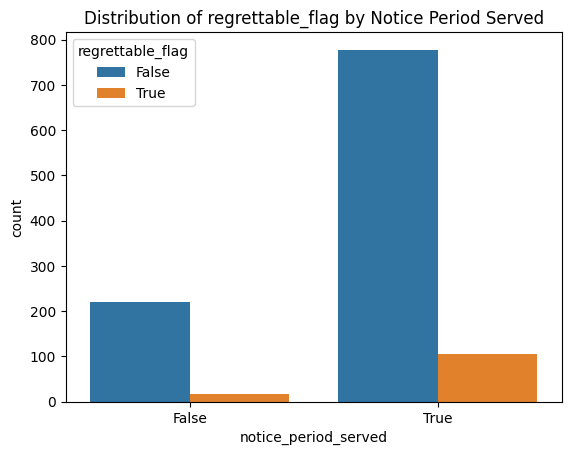

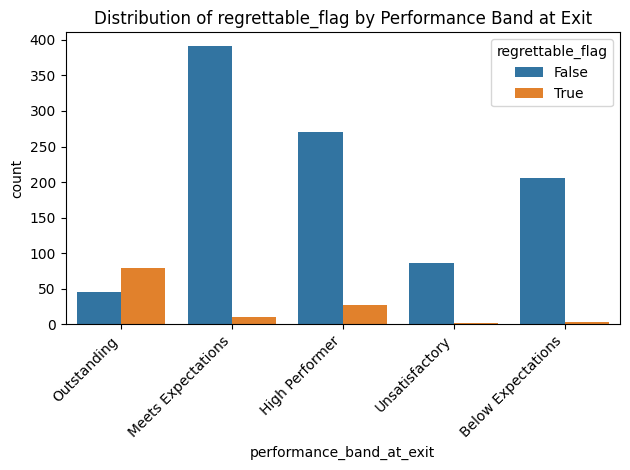

In [ ]:
import matplotlib.pyplot as plt

# Assuming target_col is 'regrettable_flag' from previous cells
# Using existing categorical columns from temp_df

sns.countplot(data=temp_df, x="exit_type", hue=target_col)
plt.title(f"Distribution of {target_col} by Exit Type")
plt.show()

sns.countplot(data=temp_df, x="pathway", hue=target_col)
plt.title(f"Distribution of {target_col} by Pathway")
plt.show()

sns.countplot(data=temp_df, x="notice_period_served", hue=target_col)
plt.title(f"Distribution of {target_col} by Notice Period Served")
plt.show()

sns.countplot(data=temp_df, x="performance_band_at_exit", hue=target_col)
plt.title(f"Distribution of {target_col} by Performance Band at Exit")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

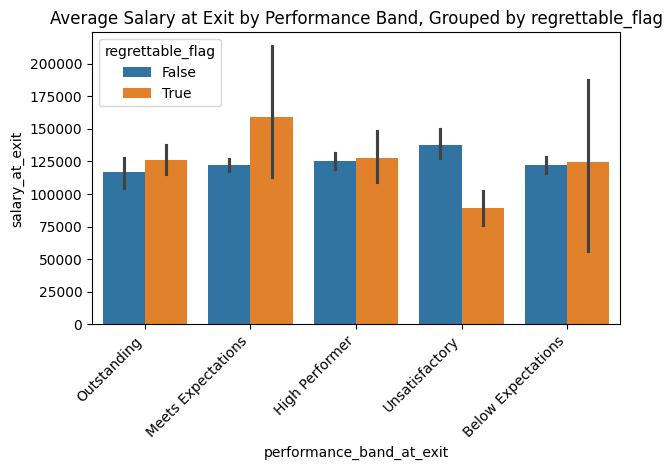

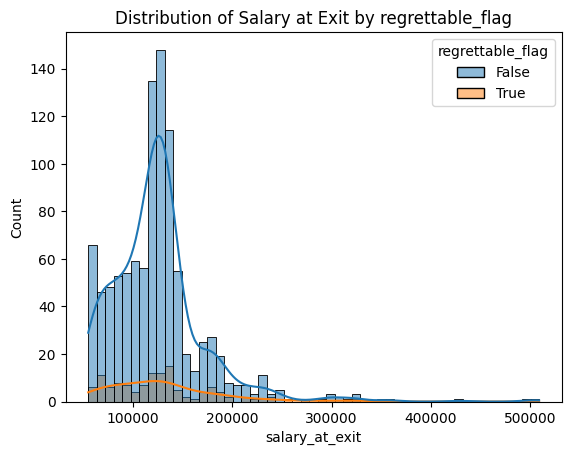

In [ ]:
import matplotlib.pyplot as plt

# Using an existing numerical column from temp_df for comparison with the target

sns.barplot(data=temp_df, x="performance_band_at_exit", y="salary_at_exit", hue=target_col)
plt.title(f"Average Salary at Exit by Performance Band, Grouped by {target_col}")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# As an alternative, you could also plot numerical features directly
sns.histplot(data=temp_df, x="salary_at_exit", hue=target_col, kde=True)
plt.title(f"Distribution of Salary at Exit by {target_col}")
plt.show()

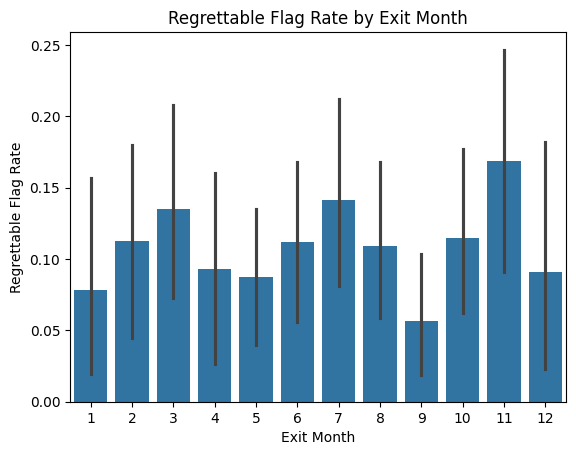

In [ ]:
temp_df["exit_date"]  = pd.to_datetime(temp_df["exit_date"])
temp_df["exit_month"] = temp_df["exit_date"].dt.month
sns.barplot(data=temp_df, x="exit_month", y="regrettable_flag")      # regrettable flag rate by exit month
plt.title(f"Regrettable Flag Rate by Exit Month")
plt.xlabel("Exit Month")
plt.ylabel("Regrettable Flag Rate")
plt.show()

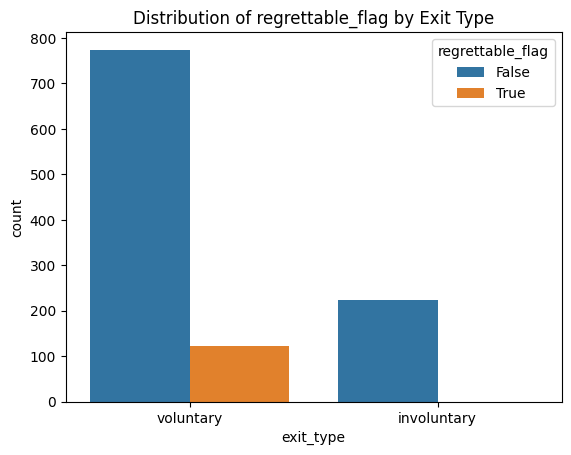

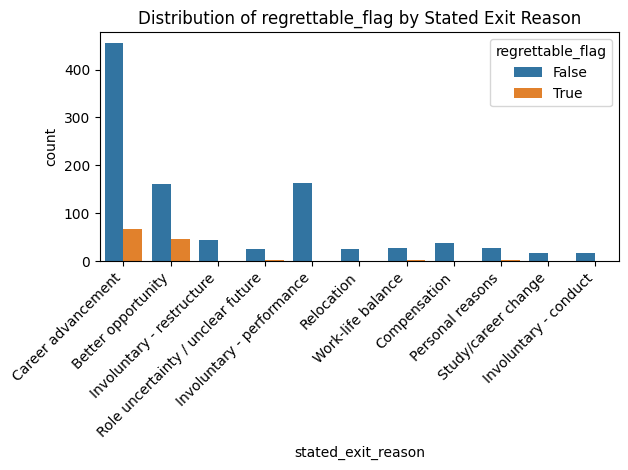

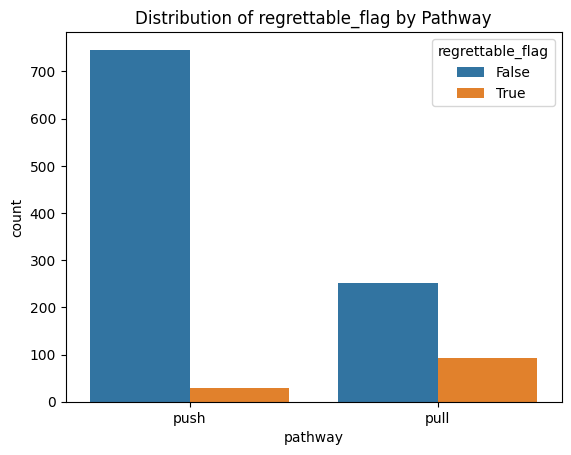

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

target_col = "regrettable_flag"

# Using existing categorical columns from temp_df

sns.countplot(data=temp_df, x="exit_type", hue=target_col)
plt.title(f"Distribution of {target_col} by Exit Type")
plt.show()

sns.countplot(data=temp_df, x="stated_exit_reason", hue=target_col)
plt.title(f"Distribution of {target_col} by Stated Exit Reason")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

sns.countplot(data=temp_df, x="pathway", hue=target_col)
plt.title(f"Distribution of {target_col} by Pathway")
plt.show()

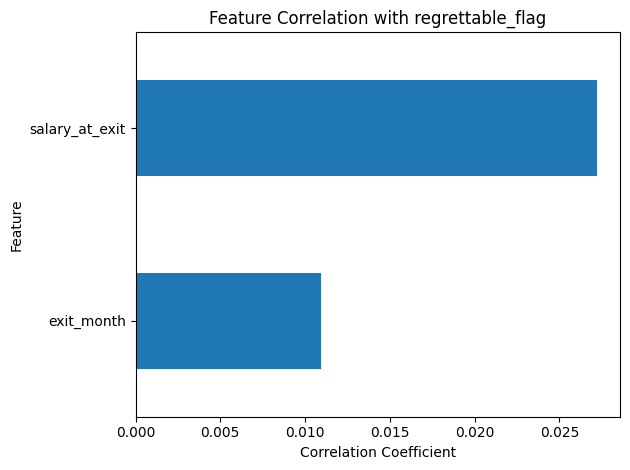

In [ ]:
temp_df['regrettable_flag'] = temp_df['regrettable_flag'].astype(int)
correlations = temp_df.select_dtypes(include="number").corr()[target_col]
feature_corr = correlations.drop(target_col).sort_values()
feature_corr.plot(kind="barh")
plt.title(f"Feature Correlation with {target_col}")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# X_train = X_train.drop("user_id", axis=1)                          # IDs carry no signal → drop
# X_train["signup_month"] = pd.to_datetime(X_train["signup_date"]).dt.month
# X_train = X_train.drop("signup_date", axis=1)                      # keep the month, drop the raw date
# X_train["is_enterprise"] = X_train["is_enterprise"].astype(int)   # True/False → 1/0
# These columns ('user_id', 'signup_date', 'is_enterprise') are not present in the current X_train DataFrame.
# If you intend to use these features, they need to be part of your initial DataFrame or generated from existing columns.

In [ ]:
# tier_company_size = {"1-10": 0, "11-50": 1, "51-200": 2, "200+": 3}
# X_train["company_size_encoded"] = X_train["company_size"].map(tier_company_size)
# The 'company_size' column is not present in the current X_train DataFrame.
# This transformation needs to occur on the original DataFrame before splitting and saving if this feature is desired.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# cat_cols = ["region_imputed", "industry", "acquisition_channel"]
# encoder = OneHotEncoder(drop="first", sparse_output=False)
# encoded = encoder.fit_transform(X_train[cat_cols])
# These columns ('region_imputed', 'industry', 'acquisition_channel') are not present in the current X_train DataFrame.
# If you intend to use these features, they need to be part of your initial DataFrame or generated from existing columns on the original 'df' before splitting.

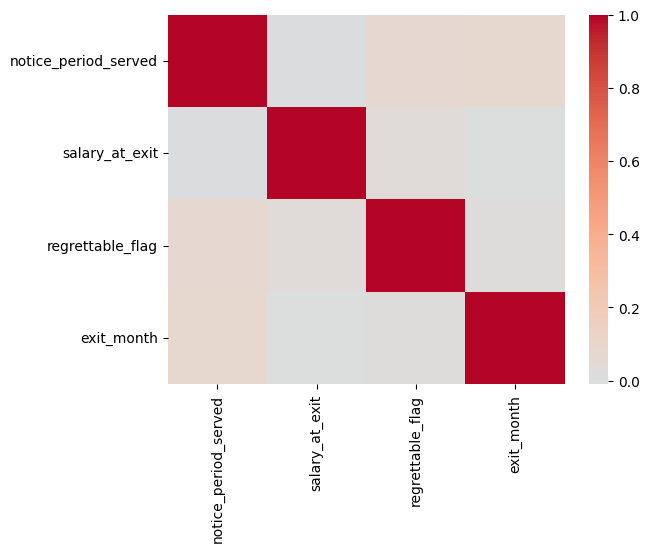

In [ ]:
# First, ensure all boolean columns are converted to int for correlation calculation
for col in temp_df.select_dtypes(include='bool').columns:
    temp_df[col] = temp_df[col].astype(int)

# Then, select only numeric columns for correlation matrix
numeric_temp_df = temp_df.select_dtypes(include="number")
corr_matrix = numeric_temp_df.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)

# The target_col must be present in the numeric_temp_df to proceed.
correlations   = corr_matrix[target_col].abs()
strong_features = correlations[correlations > 0.05].index.tolist()   # keep |corr| > 0.05

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap

In [ ]:
rf_model = RandomForestClassifier(random_state=42)

# Apply the preprocessor to X_train and X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

rf_model.fit(X_train_processed, y_train.values.ravel())

RandomForestClassifier(random_state=42)

In [ ]:
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(X_train_processed, y_train.values.ravel())

y_pred       = rf_model.predict(X_test_processed)                  # class: churn / no-churn
y_pred_proba = rf_model.predict_proba(X_test_processed)[:, 1]      # probability of churn

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:",    recall_score(y_test, y_pred))
print("F1:",        f1_score(y_test, y_pred))
print("ROC AUC:",   roc_auc_score(y_test, y_pred_proba))

Precision: 0.6
Recall: 0.4838709677419355
F1: 0.5357142857142857
ROC AUC: 0.8857364943645551


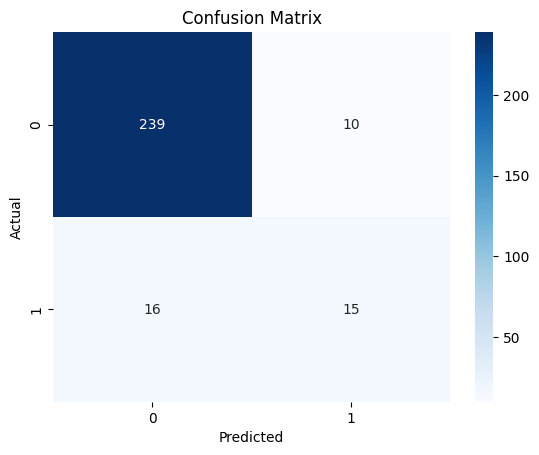

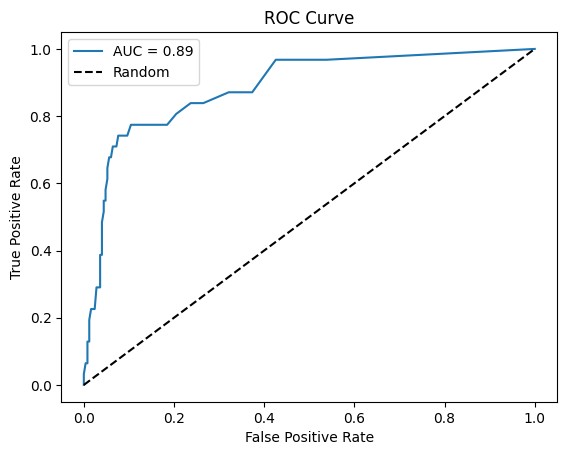

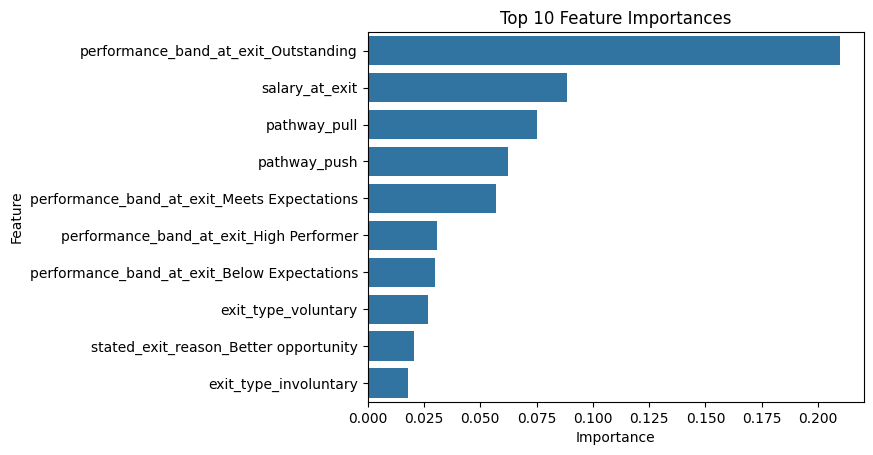

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Confusion matrix - the raw counts of right/wrong for each class
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 2. ROC curve - the trade-off between catching churners and false alarms
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.2f}")
plt.plot([0, 1], [0, 1], 'k--', label='Random') # Add random guess line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# 3. Feature importance - which features drove the predictions
# Get feature names after one-hot encoding
feature_names = preprocessor.named_transformers_['categorical']['encoder'].get_feature_names_out(categorical_cols).tolist() + numeric_cols.tolist()

feat_imp = pd.DataFrame({"feature": feature_names,
                         "importance": rf_model.feature_importances_})
# Sort by importance and take the top 10
feat_imp = feat_imp.sort_values(by='importance', ascending=False).head(10)
sns.barplot(data=feat_imp, x="importance", y="feature")
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators":      [100, 200, 300, 500],   # number of trees (more = stabler, slower)
    "max_depth":         [5, 10, 20, None],       # tree depth (deeper = more complex, can overfit)
    "min_samples_split": [2, 5, 10],              # samples needed to split (higher = more conservative)
    "min_samples_leaf":  [1, 2, 4],               # samples in a leaf (prevents tiny overfit branches)
    "max_features":      ["sqrt", "log2"],        # features considered per split
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20, cv=5, scoring="f1", random_state=42, n_jobs=-1
)

# Use the already processed X_train_processed and y_train
rf_search.fit(X_train_processed, y_train.values.ravel())
best_rf = rf_search.best_estimator_

# Also fit the xgb_model with processed data for subsequent SHAP analysis if needed
# Note: This is a placeholder. If xgb_model is meant to be tuned separately, it should have its own search.
# For now, applying the preprocessor to the raw X_train for xgb_model if it's meant to be fit directly here.
# If best_xgb is intended to come from a separate tuning, ensure it's defined and fitted appropriately.
# For consistency, I will assume xgb_model needs processed data as well if it's used in subsequent cells.
# However, the user explicitly asked to fix the 'fdZfdinuojKS' cell only, which is for rf_search.
# The error in 'JYH_DcMeokR-' for xgb_model will need a similar fix if it's meant to be run.
# For now, focus on rf_search:

# After finding best_rf, you might want to evaluate it or use it for predictions
# y_pred_rf_tuned = best_rf.predict(X_test_processed)
# y_pred_proba_rf_tuned = best_rf.predict_proba(X_test_processed)[:, 1]

In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=42
)
# Use the already processed X_train_processed and y_train
xgb_model.fit(X_train_processed, y_train.values.ravel())
y_pred_proba = xgb_model.predict_proba(X_test_processed)[:, 1]

best_xgb = xgb_model # Assign the trained model to best_xgb for SHAP analysis

In [ ]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

/tmp/ipykernel_1655/2193921735.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
/tmp/ipykernel_1655/2193921735.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]


In [ ]:
threshold = 0.2
y_pred_adjusted = (y_pred_proba >= threshold).astype(int)   # catch more churners

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1 = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
best_threshold = thresholds[np.nanargmax(f1)]

X_train_processed is sparse, converting to dense array.
Shape of X_train_processed after re-transform and potential dense conversion: (1120, 456)
Shape of shap_values: (1120, 456)
Shape of X_train_processed before DataFrame creation (final check): (1120, 456)
Length of feature_names: 456



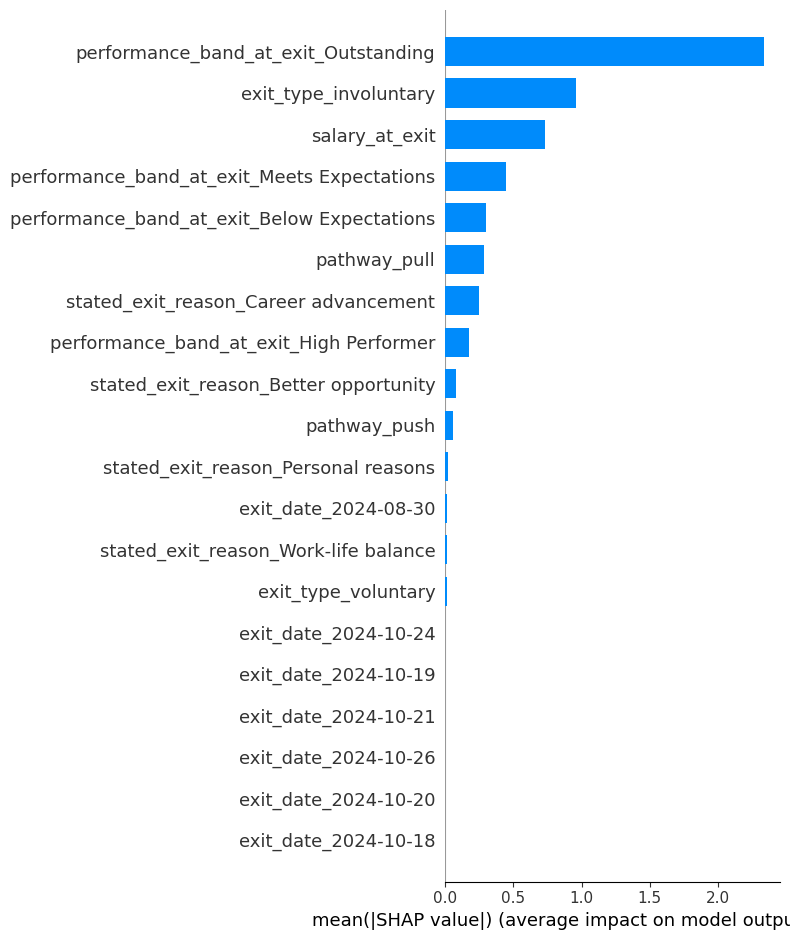

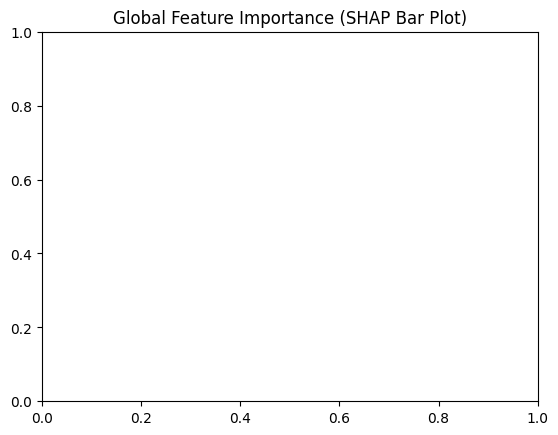

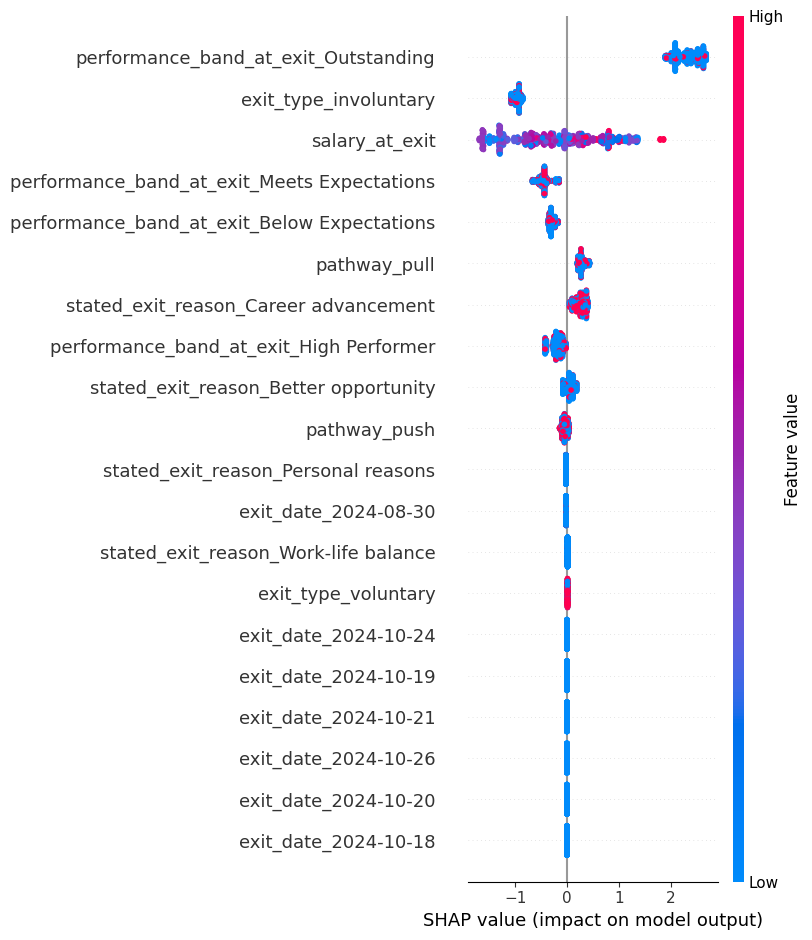

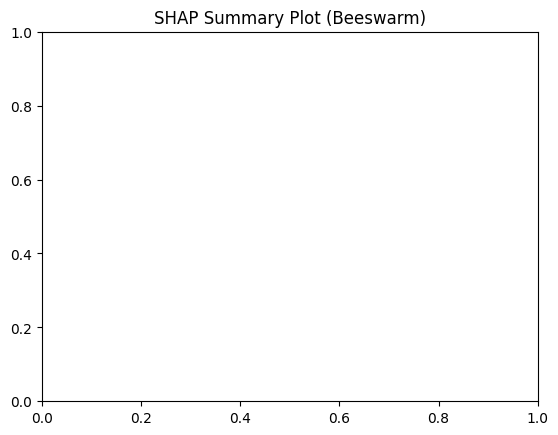

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting
import numpy as np # Import numpy for isinstance check
from scipy.sparse import issparse # To check if it's a sparse matrix

# Re-apply the preprocessor to X_train to ensure X_train_processed is correctly formed.
# This is a defensive step in case X_train_processed was unexpectedly altered or corrupted.
# It relies on 'preprocessor' (which was fitted) and 'X_train' (the original raw training features)
# being accessible from previous cells.
X_train_processed = preprocessor.transform(X_train)

# Explicitly convert to dense array if it's a sparse matrix (which it will be due to OneHotEncoder default)
if issparse(X_train_processed):
    print("X_train_processed is sparse, converting to dense array.")
    X_train_processed = X_train_processed.toarray()

print(f"Shape of X_train_processed after re-transform and potential dense conversion: {X_train_processed.shape}") # Debug print

explainer   = shap.TreeExplainer(best_xgb)
# Use the correctly re-calculated preprocessed training data for SHAP value calculation
shap_values = explainer.shap_values(X_train_processed)
print(f"Shape of shap_values: {shap_values.shape}") # Debug print

# Create a DataFrame from the processed training data for better visualization with feature names
# 'feature_names' should be available from cell GJbxgcI5ofpW
print(f"Shape of X_train_processed before DataFrame creation (final check): {X_train_processed.shape}") # Debug print
print(f"Length of feature_names: {len(feature_names)}\n") # Debug print (added newline for clarity)
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)

# Global feature importance (bar plot)
shap.summary_plot(shap_values, X_train_processed_df, plot_type="bar")   # global: overall feature impact
plt.title('Global Feature Importance (SHAP Bar Plot)')
plt.show()

# Beeswarm plot: how individual feature values push predictions
shap.summary_plot(shap_values, X_train_processed_df)                    # beeswarm: how values push predictions
plt.title('SHAP Summary Plot (Beeswarm)')
plt.show()

# Local explanation for the first customer
# explainer.expected_value can be a scalar or an array; for binary classification, typically scalar or take [0]
base_value = explainer.expected_value
if isinstance(base_value, np.ndarray) and base_value.ndim > 0:
    base_value = base_value[0] # Take the expected value for the positive class

shap.force_plot(base_value,                 # expected value from the model
                shap_values[0],             # SHAP values for the first instance
                X_train_processed_df.iloc[[0]]) # Features for the first instance (as a DataFrame row)
plt.show()